In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm
import warnings
warnings.filterwarnings("ignore")

# Copy bs_price and bs_greeks from Phase 1 (self-contained here)
def bs_d1_d2(S, K, T, r, sigma, q=0.0):
    with np.errstate(divide="ignore", invalid="ignore"):
        d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)
    return d1, d2

def bs_price(S, K, T, r, sigma, q=0.0, option_type="call"):
    S, K, T, sigma = map(np.asarray, [S, K, T, sigma])
    if np.all(T <= 0):
        return np.maximum(S - K, 0.0) if option_type == "call" else np.maximum(K - S, 0.0)
    d1, d2 = bs_d1_d2(S, K, T, r, sigma, q)
    if option_type == "call":
        return S * np.exp(-q*T) * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)
    return K * np.exp(-r*T) * norm.cdf(-d2) - S * np.exp(-q*T) * norm.cdf(-d1)

print("Phase 1 functions loaded ✓")

Phase 1 functions loaded ✓


In [ ]:
def binomial_tree(S, K, T, r, sigma, q=0.0,
                  N=200, option_type="call", exercise="european"):
    """
    Price a European or American option using the CRR binomial tree.

    Parameters
    ----------
    N        : int  — number of time steps (more = more accurate, slower)
    exercise : str  — "european" or "american"

    Returns
    -------
    price : float
    """
    dt = T / N                         

    # CRR parameters
    u  = np.exp(sigma * np.sqrt(dt))   
    d  = 1.0 / u                        
    p  = (np.exp((r - q) * dt) - d) / (u - d)   # risk-neutral up probability
    disc = np.exp(-r * dt)              # one-step discount factor

    # Sanity check: p must be in (0,1) for no-arbitrage
    assert 0 < p < 1, f"Invalid risk-neutral prob p={p:.4f} — reduce dt or check params"

    # ── Terminal stock prices (vectorized) ──
    # At step N, node j has gone up j times and down (N-j) times
    # S_j = S · u^j · d^(N-j) = S · u^(2j-N)
    j       = np.arange(N + 1)         
    S_T     = S * (u ** (2 * j - N))        

    # Terminal payoffs
    if option_type == "call":
        V = np.maximum(S_T - K, 0.0)
    else:
        V = np.maximum(K - S_T, 0.0)

    # Backward inductio
    # At each step, fold the value vector from N+1 nodes down to N nodes,
    # then N-1, ..., until we reach a single node at t=0.
    for i in range(N - 1, -1, -1):
        # Risk-neutral expectation, discounted one step
        V = disc * (p * V[1:] + (1 - p) * V[:-1])

        if exercise == "american":
            # Stock prices at this step
            S_i = S * (u ** (2 * np.arange(i + 1) - i))
            # Early exercise value
            if option_type == "call":
                intrinsic = np.maximum(S_i - K, 0.0)
            else:
                intrinsic = np.maximum(K - S_i, 0.0)
            # Take the max of hold vs exercise
            V = np.maximum(V, intrinsic)

    return float(V[0])


# Smoke test
params = dict(S=100, K=100, T=1.0, r=0.05, sigma=0.20, q=0.0)
bs_call  = float(bs_price(**params, option_type="call"))
bin_call = binomial_tree(**params, N=500, option_type="call", exercise="european")

print(f"Black-Scholes call : {bs_call:.4f}")
print(f"Binomial (N=500)   : {bin_call:.4f}")
print(f"Difference         : {abs(bs_call - bin_call):.6f}")

Black-Scholes call : 10.4506
Binomial (N=500)   : 10.4466
Difference         : 0.003998


In [3]:
print("--- Early Exercise Premium ---")
for K in [90, 100, 110]:
    euro_put = binomial_tree(**{**params, "K": K}, N=500,
                             option_type="put", exercise="european")
    amer_put = binomial_tree(**{**params, "K": K}, N=500,
                             option_type="put", exercise="american")
    premium  = amer_put - euro_put
    print(f"  K={K}: European={euro_put:.4f}, American={amer_put:.4f}, "
          f"Premium={premium:.4f} ({premium/euro_put*100:.2f}%)")

# American call on non-dividend paying stock
amer_call = binomial_tree(**params, N=500, option_type="call", exercise="american")
euro_call = binomial_tree(**params, N=500, option_type="call", exercise="european")
print(f"\nAmerican call premium (no dividends): {amer_call - euro_call:.6f}  ← should be ~0")

--- Early Exercise Premium ---
  K=90: European=2.3094, American=2.4724, Premium=0.1630 (7.06%)


  K=100: European=5.5695, American=6.0888, Premium=0.5193 (9.32%)
  K=110: European=10.6775, American=11.9744, Premium=1.2969 (12.15%)

American call premium (no dividends): 0.000000  ← should be ~0


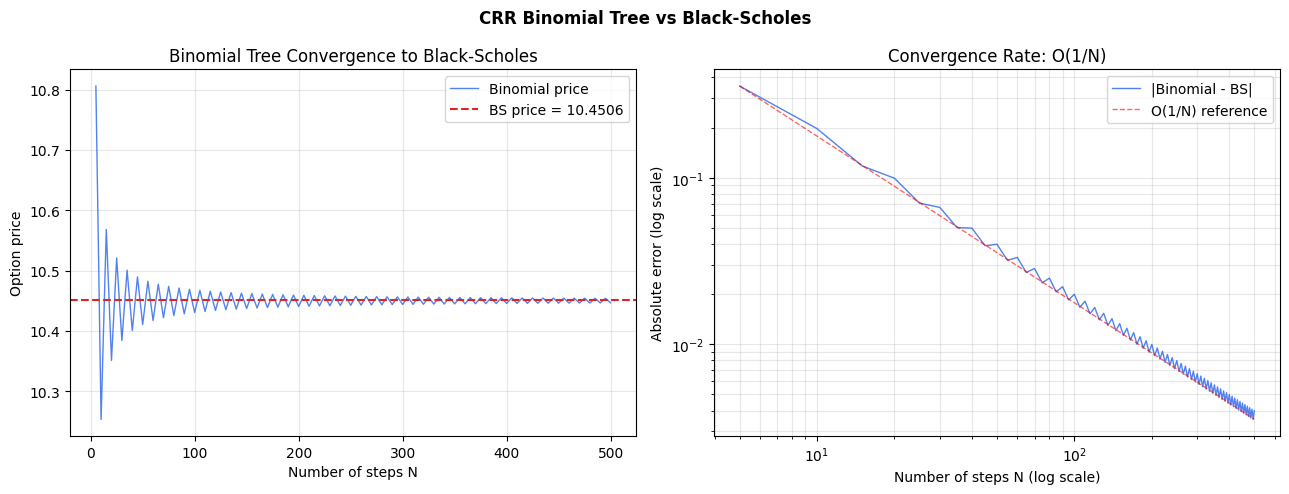

In [4]:
N_values  = list(range(5, 501, 5))
bin_prices = [binomial_tree(**params, N=N, option_type="call", exercise="european")
              for N in N_values]
bs_ref     = float(bs_price(**params, option_type="call"))
errors     = [abs(p - bs_ref) for p in bin_prices]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: price convergence
ax = axes[0]
ax.plot(N_values, bin_prices, lw=1, color="#2563EB", alpha=0.8, label="Binomial price")
ax.axhline(bs_ref, color="#DC2626", lw=1.5, ls="--", label=f"BS price = {bs_ref:.4f}")
ax.set_xlabel("Number of steps N")
ax.set_ylabel("Option price")
ax.set_title("Binomial Tree Convergence to Black-Scholes")
ax.legend()
ax.grid(alpha=0.3)

# Right: log error (shows O(1/N) convergence rate)
ax = axes[1]
ax.loglog(N_values, errors, lw=1, color="#2563EB", alpha=0.8, label="|Binomial - BS|")
# Reference O(1/N) line
ref_line = [errors[0] * N_values[0] / N for N in N_values]
ax.loglog(N_values, ref_line, "r--", lw=1, alpha=0.6, label="O(1/N) reference")
ax.set_xlabel("Number of steps N (log scale)")
ax.set_ylabel("Absolute error (log scale)")
ax.set_title("Convergence Rate: O(1/N)")
ax.legend()
ax.grid(alpha=0.3, which="both")

plt.suptitle("CRR Binomial Tree vs Black-Scholes", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/binomial_convergence.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
def simulate_gbm(S, T, r, sigma, q=0.0, N_paths=10_000, M=252, seed=42):
    """
    Simulate N_paths GBM paths with M time steps each.

    Returns
    -------
    S_paths : np.ndarray, shape (N_paths, M+1)
              S_paths[:, 0]  = S (initial)
              S_paths[:, -1] = terminal prices
    dt      : float — time step size
    """
    rng  = np.random.default_rng(seed)
    dt   = T / M

    # Drift and diffusion terms (Ito-corrected)
    drift = (r - q - 0.5 * sigma**2) * dt
    diff  = sigma * np.sqrt(dt)

    # Standard normal shocks: shape (N_paths, M)
    Z = rng.standard_normal((N_paths, M))

    # Log-return increments
    log_returns = drift + diff * Z          

    log_S = np.log(S) + np.concatenate(
        [np.zeros((N_paths, 1)),             
         np.cumsum(log_returns, axis=1)],  
        axis=1
    )

    return np.exp(log_S), dt                

In [6]:
def mc_european(S, K, T, r, sigma, q=0.0, option_type="call",
                N_paths=100_000, M=252, seed=42):
    """
    Price a European option via Monte Carlo.

    Returns
    -------
    price : float — MC estimate
    se    : float — standard error of estimate
    ci    : tuple — 95% confidence interval (lower, upper)
    """
    S_paths, _ = simulate_gbm(S, T, r, sigma, q, N_paths, M, seed)
    S_T        = S_paths[:, -1]              # terminal prices only

    if option_type == "call":
        payoffs = np.maximum(S_T - K, 0.0)
    else:
        payoffs = np.maximum(K - S_T, 0.0)

    disc_payoffs = np.exp(-r * T) * payoffs
    price = disc_payoffs.mean()
    se    = disc_payoffs.std() / np.sqrt(N_paths)
    ci    = (price - 1.96 * se, price + 1.96 * se)

    return price, se, ci


# Compare MC vs BS
print("--- Monte Carlo vs Black-Scholes (European) ---\n")
print(f"{'Option':<10} {'BS Price':>10} {'MC Price':>10} {'Std Err':>10} {'95% CI':>22} {'In CI?':>7}")
print("-" * 75)

for opt in ["call", "put"]:
    bs   = float(bs_price(**params, option_type=opt))
    mc, se, ci = mc_european(**params, option_type=opt, N_paths=100_000)
    in_ci = ci[0] <= bs <= ci[1]
    print(f"{opt:<10} {bs:>10.4f} {mc:>10.4f} {se:>10.5f} "
          f"  [{ci[0]:.4f}, {ci[1]:.4f}]  {'✓' if in_ci else '✗':>7}")

--- Monte Carlo vs Black-Scholes (European) ---

Option       BS Price   MC Price    Std Err                 95% CI  In CI?
---------------------------------------------------------------------------
call          10.4506    10.4829    0.04689   [10.3909, 10.5748]        ✓
put            5.5735     5.5676    0.02737   [5.5140, 5.6213]        ✓


In [ ]:
def mc_european_vr(S, K, T, r, sigma, q=0.0, option_type="call",
                   N_paths=100_000, M=252, seed=42):
    """
    European MC with antithetic variates AND control variates.
    Returns prices and std errors for: plain, antithetic, control variate.
    """
    rng  = np.random.default_rng(seed)
    dt   = T / M
    drift = (r - q - 0.5 * sigma**2) * dt
    diff  = sigma * np.sqrt(dt)

    # Half the paths (antithetic doubles them)
    Z    = rng.standard_normal((N_paths // 2, M))

    def path_terminal(shocks):
        log_ret = drift + diff * shocks
        return S * np.exp(np.sum(log_ret, axis=1))

    S_T_pos = path_terminal(Z)       
    S_T_neg = path_terminal(-Z)      

    disc = np.exp(-r * T)

    def payoff(S_T):
        return np.maximum(S_T - K, 0) if option_type == "call" else np.maximum(K - S_T, 0)

    # Plain MC (using +Z only, N_paths/2 paths)
    p_plain = disc * payoff(S_T_pos)
    price_plain = p_plain.mean()
    se_plain    = p_plain.std() / np.sqrt(len(p_plain))

    # Antithetic variates
    p_anti   = disc * (payoff(S_T_pos) + payoff(S_T_neg)) / 2
    price_av = p_anti.mean()
    se_av    = p_anti.std() / np.sqrt(len(p_anti))

    # Control variates (on antithetic pairs)
    # Control: discounted stock price (known mean = S * e^{-qT})
    ctrl     = disc * (S_T_pos + S_T_neg) / 2    
    ctrl_mean = S * np.exp(-q * T)               

    # Optimal b via OLS regression of payoff on control
    cov_mat = np.cov(p_anti, ctrl)
    b_opt   = cov_mat[0, 1] / cov_mat[1, 1]    

    p_cv    = p_anti - b_opt * (ctrl - ctrl_mean)
    price_cv = p_cv.mean()
    se_cv    = p_cv.std() / np.sqrt(len(p_cv))

    return {
        "plain":      (price_plain, se_plain),
        "antithetic": (price_av,    se_av),
        "control_var":(price_cv,    se_cv),
    }


bs_ref = float(bs_price(**params, option_type="call"))
results = mc_european_vr(**params, option_type="call", N_paths=100_000)

print("\n--- Variance Reduction Comparison ---\n")
print(f"Black-Scholes reference: {bs_ref:.4f}\n")
print(f"{'Method':<15} {'Price':>8} {'Std Err':>10} {'Var Reduction':>15}")
print("-" * 52)
se_base = results["plain"][1]
for method, (price, se) in results.items():
    vr = (1 - (se / se_base)**2) * 100 if method != "plain" else 0.0
    print(f"{method:<15} {price:>8.4f} {se:>10.5f} {vr:>14.1f}%")


--- Variance Reduction Comparison ---

Black-Scholes reference: 10.4506

Method             Price    Std Err   Var Reduction
----------------------------------------------------
plain            10.4526    0.06603            0.0%
antithetic       10.4333    0.03307           74.9%
control_var      10.4339    0.00888           98.2%


In [ ]:
def mc_asian(S, K, T, r, sigma, q=0.0, option_type="call",
             N_paths=100_000, M=252, seed=42):
    """Arithmetic average Asian option via Monte Carlo."""
    S_paths, _ = simulate_gbm(S, T, r, sigma, q, N_paths, M, seed)

    S_avg = S_paths[:, 1:].mean(axis=1)   

    if option_type == "call":
        payoffs = np.maximum(S_avg - K, 0.0)
    else:
        payoffs = np.maximum(K - S_avg, 0.0)

    disc_payoffs = np.exp(-r * T) * payoffs
    price = disc_payoffs.mean()
    se    = disc_payoffs.std() / np.sqrt(N_paths)
    return price, se


def mc_barrier(S, K, T, r, sigma, q=0.0, H=90.0,
               barrier_type="down-out", option_type="call",
               N_paths=100_000, M=252, seed=42):
    """
    Barrier option pricing via Monte Carlo.

    Parameters
    ----------
    H            : float — barrier level
    barrier_type : str   — "down-out", "down-in", "up-out", "up-in"
    """
    S_paths, _ = simulate_gbm(S, T, r, sigma, q, N_paths, M, seed)
    S_T        = S_paths[:, -1]

    # Check barrier crossing across entire path
    S_min = S_paths.min(axis=1)   
    S_max = S_paths.max(axis=1)   

    if barrier_type == "down-out":
        alive = S_min > H        
    elif barrier_type == "down-in":
        alive = S_min <= H         
    elif barrier_type == "up-out":
        alive = S_max < H
    elif barrier_type == "up-in":
        alive = S_max >= H
    else:
        raise ValueError(f"Unknown barrier_type: {barrier_type}")

    if option_type == "call":
        payoffs = np.where(alive, np.maximum(S_T - K, 0.0), 0.0)
    else:
        payoffs = np.where(alive, np.maximum(K - S_T, 0.0), 0.0)

    disc_payoffs = np.exp(-r * T) * payoffs
    price = disc_payoffs.mean()
    se    = disc_payoffs.std() / np.sqrt(N_paths)
    return price, se


# Price all exotic variants
N = 200_000
print("--- Exotic Option Pricing ---\n")

vanilla_call, se_v = mc_european(**params, option_type="call", N_paths=N)[:2]
asian_call,   se_a = mc_asian(**params,    option_type="call", N_paths=N)
down_out,     se_do = mc_barrier(**params, H=90, barrier_type="down-out", N_paths=N)
down_in,      se_di = mc_barrier(**params, H=90, barrier_type="down-in",  N_paths=N)
bs_vanilla = float(bs_price(**params, option_type="call"))

print(f"{'Option':<25} {'Price':>8} {'Std Err':>9}")
print("-" * 44)
print(f"{'Vanilla call (BS)':<25} {bs_vanilla:>8.4f} {'(exact)':>9}")
print(f"{'Vanilla call (MC)':<25} {vanilla_call:>8.4f} {se_v:>9.5f}")
print(f"{'Asian call (arith avg)':<25} {asian_call:>8.4f} {se_a:>9.5f}")
print(f"{'Down-and-Out call H=90':<25} {down_out:>8.4f} {se_do:>9.5f}")
print(f"{'Down-and-In  call H=90':<25} {down_in:>8.4f} {se_di:>9.5f}")
print(f"\nBarrier parity check:")
print(f"  Down-Out + Down-In = {down_out + down_in:.4f}")
print(f"  Vanilla MC         = {vanilla_call:.4f}")
print(f"  Difference         = {abs(down_out + down_in - vanilla_call):.5f}  ← should be ~0")
print(f"\nAsian < Vanilla: {asian_call:.4f} < {vanilla_call:.4f}  "
      f"{'✓' if asian_call < vanilla_call else '✗'} (averaging reduces optionality)")

--- Exotic Option Pricing ---

Option                       Price   Std Err
--------------------------------------------
Vanilla call (BS)          10.4506   (exact)
Vanilla call (MC)          10.5047   0.03311
Asian call (arith avg)      5.8048   0.01793
Down-and-Out call H=90      8.9884   0.03301
Down-and-In  call H=90      1.5163   0.01195

Barrier parity check:
  Down-Out + Down-In = 10.5047
  Vanilla MC         = 10.5047
  Difference         = 0.00000  ← should be ~0

Asian < Vanilla: 5.8048 < 10.5047  ✓ (averaging reduces optionality)


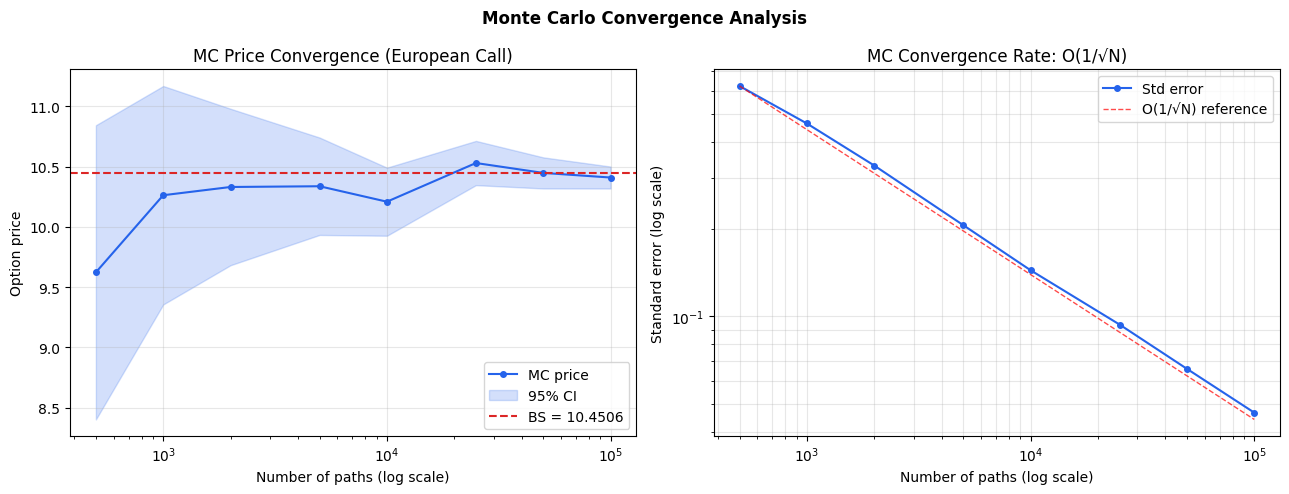

In [9]:
path_counts = [500, 1000, 2000, 5000, 10000, 25000, 50000, 100000]
mc_prices, mc_ses = [], []

for N in path_counts:
    price, se, _ = mc_european(**params, option_type="call", N_paths=N, seed=99)
    mc_prices.append(price)
    mc_ses.append(se)

mc_prices = np.array(mc_prices)
mc_ses    = np.array(mc_ses)
bs_ref    = float(bs_price(**params, option_type="call"))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: price + confidence bands
ax = axes[0]
ax.plot(path_counts, mc_prices, "o-", color="#2563EB", lw=1.5, ms=4, label="MC price")
ax.fill_between(path_counts,
                mc_prices - 1.96 * mc_ses,
                mc_prices + 1.96 * mc_ses,
                alpha=0.2, color="#2563EB", label="95% CI")
ax.axhline(bs_ref, color="#DC2626", lw=1.5, ls="--", label=f"BS = {bs_ref:.4f}")
ax.set_xscale("log")
ax.set_xlabel("Number of paths (log scale)")
ax.set_ylabel("Option price")
ax.set_title("MC Price Convergence (European Call)")
ax.legend()
ax.grid(alpha=0.3)

# Right: std error vs N_paths (shows O(1/√N) rate)
ax = axes[1]
ax.loglog(path_counts, mc_ses, "o-", color="#2563EB", lw=1.5, ms=4, label="Std error")
ref = [mc_ses[0] * np.sqrt(path_counts[0] / N) for N in path_counts]
ax.loglog(path_counts, ref, "r--", lw=1, alpha=0.7, label="O(1/√N) reference")
ax.set_xlabel("Number of paths (log scale)")
ax.set_ylabel("Standard error (log scale)")
ax.set_title("MC Convergence Rate: O(1/√N)")
ax.legend()
ax.grid(alpha=0.3, which="both")

plt.suptitle("Monte Carlo Convergence Analysis", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/mc_convergence.png", dpi=150, bbox_inches="tight")
plt.show()

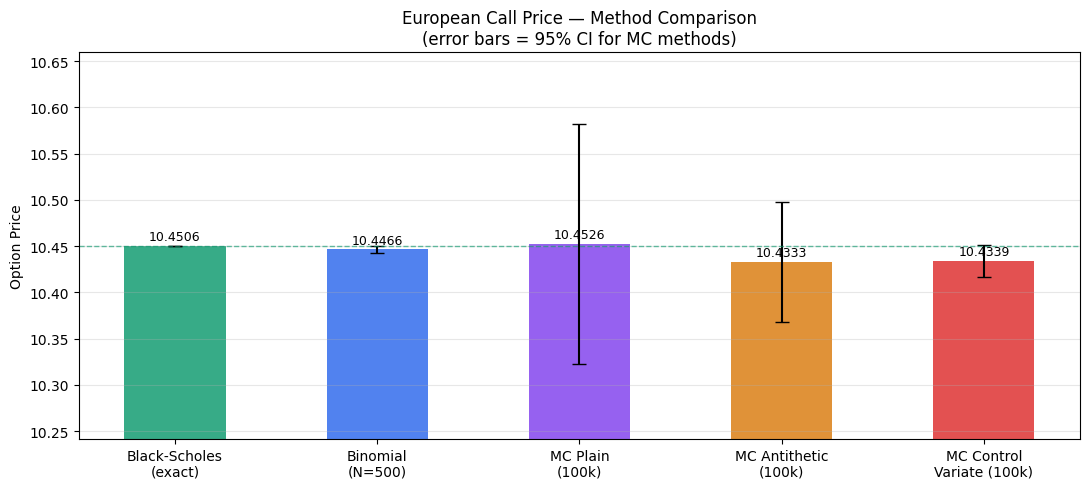

In [10]:
methods = ["Black-Scholes\n(exact)", "Binomial\n(N=500)", "MC Plain\n(100k)",
           "MC Antithetic\n(100k)", "MC Control\nVariate (100k)"]

prices = [
    float(bs_price(**params, option_type="call")),
    binomial_tree(**params, N=500, option_type="call"),
    results["plain"][0],
    results["antithetic"][0],
    results["control_var"][0],
]
errors_bar = [0,
              abs(prices[1] - prices[0]),
              results["plain"][1]    * 1.96,
              results["antithetic"][1] * 1.96,
              results["control_var"][1] * 1.96,
]

fig, ax = plt.subplots(figsize=(11, 5))
colors  = ["#059669", "#2563EB", "#7C3AED", "#D97706", "#DC2626"]
bars    = ax.bar(methods, prices, color=colors, alpha=0.8, width=0.5,
                 yerr=errors_bar, capsize=5, error_kw={"elinewidth": 1.5})
ax.axhline(prices[0], color="#059669", ls="--", lw=1, alpha=0.6)

for bar, price in zip(bars, prices):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f"{price:.4f}", ha="center", va="bottom", fontsize=9)

ax.set_ylabel("Option Price")
ax.set_title("European Call Price — Method Comparison\n(error bars = 95% CI for MC methods)")
ax.set_ylim(prices[0] * 0.98, prices[0] * 1.02)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/method_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
print("\n" + "="*60)
print("PHASE 3 VALIDATION SUITE")
print("="*60)

passed = failed = 0

def test(name, condition, detail=""):
    global passed, failed
    if condition:
        print(f"  ✓ {name}")
        passed += 1
    else:
        print(f"  ✗ {name}  {detail}")
        failed += 1

# Binomial converges to BS
print("\n[1] Binomial → Black-Scholes convergence")
for N, tol in [(50, 0.05), (200, 0.01), (500, 0.005)]:
    b = binomial_tree(**params, N=N, option_type="call")
    test(f"N={N}, tol={tol}", abs(b - bs_ref) < tol, f"diff={abs(b-bs_ref):.5f}")

# American put >= European put
print("\n[2] American put >= European put")
for K in [90, 100, 110]:
    eu = binomial_tree(**{**params,"K":K}, N=300, option_type="put", exercise="european")
    am = binomial_tree(**{**params,"K":K}, N=300, option_type="put", exercise="american")
    test(f"K={K}: Am={am:.4f} >= Eu={eu:.4f}", am >= eu - 1e-8)

# American call = European call (no dividends)
print("\n[3] American call = European call (no dividends)")
ac = binomial_tree(**params, N=300, option_type="call", exercise="american")
ec = binomial_tree(**params, N=300, option_type="call", exercise="european")
test("No early exercise premium on call", abs(ac - ec) < 0.001, f"diff={abs(ac-ec):.5f}")

# MC within 2 std errors of BS
print("\n[4] MC within 2 std errors of BS")
for opt in ["call", "put"]:
    bs  = float(bs_price(**params, option_type=opt))
    mc, se, _ = mc_european(**params, option_type=opt, N_paths=100_000)
    test(f"{opt}: |MC-BS|={abs(mc-bs):.4f} < 2*SE={2*se:.4f}",
         abs(mc - bs) < 2 * se)

# Variance reduction actually reduces variance
print("\n[5] Variance reduction decreases std error")
r_ = mc_european_vr(**params, option_type="call", N_paths=100_000)
test("Antithetic SE < Plain SE",
     r_["antithetic"][1] < r_["plain"][1],
     f"{r_['antithetic'][1]:.5f} vs {r_['plain'][1]:.5f}")
test("Control variate SE < Antithetic SE",
     r_["control_var"][1] < r_["antithetic"][1],
     f"{r_['control_var'][1]:.5f} vs {r_['antithetic'][1]:.5f}")

# Barrier parity
print("\n[6] Barrier parity: Down-Out + Down-In = Vanilla")
do, _ = mc_barrier(**params, H=90, barrier_type="down-out", N_paths=200_000)
di, _ = mc_barrier(**params, H=90, barrier_type="down-in",  N_paths=200_000)
van, se_van, _ = mc_european(**params, N_paths=200_000)
test("Parity within 2 SE", abs(do + di - van) < 2 * se_van,
     f"diff={abs(do+di-van):.4f}, 2SE={2*se_van:.4f}")

# Asian < Vanilla
print("\n[7] Asian call < Vanilla call")
asian, _ = mc_asian(**params, option_type="call", N_paths=200_000)
van2,_,_ = mc_european(**params, option_type="call", N_paths=200_000)
test("Asian < Vanilla", asian < van2, f"{asian:.4f} vs {van2:.4f}")

print(f"\n{'='*60}")
print(f"Results: {passed} passed, {failed} failed")
if failed == 0:
    print("All tests passed ✓")
    print("Ready for Phase 4 — Finite Difference Methods")
print("="*60)


PHASE 3 VALIDATION SUITE

[1] Binomial → Black-Scholes convergence
  ✓ N=50, tol=0.05
  ✓ N=200, tol=0.01
  ✓ N=500, tol=0.005

[2] American put >= European put
  ✓ K=90: Am=2.4761 >= Eu=2.3142
  ✓ K=100: Am=6.0877 >= Eu=5.5669
  ✓ K=110: Am=11.9730 >= Eu=10.6731

[3] American call = European call (no dividends)
  ✓ No early exercise premium on call

[4] MC within 2 std errors of BS
  ✓ call: |MC-BS|=0.0323 < 2*SE=0.0938
  ✓ put: |MC-BS|=0.0059 < 2*SE=0.0547

[5] Variance reduction decreases std error
  ✓ Antithetic SE < Plain SE
  ✓ Control variate SE < Antithetic SE

[6] Barrier parity: Down-Out + Down-In = Vanilla
  ✓ Parity within 2 SE

[7] Asian call < Vanilla call
  ✓ Asian < Vanilla

Results: 13 passed, 0 failed
All tests passed ✓
Ready for Phase 4 — Finite Difference Methods
